In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

pd.set_option("display.width", 1000)

In [3]:
df = pd.read_csv("dirty_financial_transactions.csv")

In [4]:
clean_df = df.copy()

In [5]:
print("Shape of Dataset:")
print(clean_df.shape)

print("\nFirst Five Rows:")
display(clean_df.head())

print("\nDataset Information:")
clean_df.info()

Shape of Dataset:
(100000, 8)

First Five Rows:


,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      94982 non-null   str    
 1   Transaction_Date    95120 non-null   str    
 2   Customer_ID         95122 non-null   str    
 3   Product_Name        100000 non-null  str    
 4   Quantity            94981 non-null   float64
 5   Price               66503 non-null   str    
 6   Payment_Method      100000 non-null  str    
 7   Transaction_Status  83321 non-null   str    
dtypes: float64(1), str(7)
memory usage: 6.1 MB


In [6]:
missing = clean_df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": round((missing / len(clean_df)) * 100, 2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

display(missing_df)

,Missing Values,Percentage (%)
Transaction_ID,5018,5.02
Transaction_Date,4880,4.88
Customer_ID,4878,4.88
Quantity,5019,5.02
Price,33497,33.50
Transaction_Status,16679,16.68


In [7]:
# Missing Values Summary

missing = clean_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": round((missing / len(clean_df)) * 100, 2)
})

display(missing_df)

,Missing Values,Percentage (%)
Price,33497,33.50
Transaction_Status,16679,16.68
Quantity,5019,5.02
Transaction_ID,5018,5.02
Transaction_Date,4880,4.88
Customer_ID,4878,4.88


In [8]:
# Replace Empty Strings with NaN

clean_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed
...,...,...,...,...,...,...,...,...
99995,NaN,2021-10-06,C1743,Headphones,-8.0,240.0032380562687,PayPal,complete
99996,T99997,2024-08-25,C4830,Smartphone,NaN,503.82951729633896,credit card,Completed
99997,T99998,2023-13-01,C280,Laptop,-10.0,NaN,PayPal,completed
99998,T99999,2020-07-12,C4059,Headphones,10.0,NaN,PayPal,Completed


In [9]:
# Missing Values After Converting Empty Strings

missing = clean_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": round((missing / len(clean_df)) * 100, 2)
})

display(missing_df)

,Missing Values,Percentage (%)
Price,33497,33.50
Transaction_Status,16679,16.68
Quantity,5019,5.02
Transaction_ID,5018,5.02
Transaction_Date,4880,4.88
Customer_ID,4878,4.88


In [10]:
# Remove rows with missing essential fields

essential_columns = [
    "Transaction_ID",
    "Transaction_Date",
    "Customer_ID",
    "Quantity"
]

clean_df.dropna(subset=essential_columns, inplace=True)

print("Dataset Shape:", clean_df.shape)

Dataset Shape: (81644, 8)


In [12]:
# Replace missing transaction status with "Unknown"

clean_df["Transaction_Status"] = clean_df["Transaction_Status"].fillna("Unknown")

In [13]:
# Remaining Missing Values

missing = clean_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": round((missing / len(clean_df)) * 100, 2)
})

display(missing_df)

,Missing Values,Percentage (%)
Price,27344,33.49


In [14]:
# Count Duplicate Rows

duplicate_count = clean_df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count}")

Duplicate Rows: 802


In [15]:
# Remove Duplicate Rows

clean_df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(clean_df.shape)

Dataset Shape After Removing Duplicates:
(80842, 8)


In [16]:
# Verify Duplicate Removal

duplicate_count = clean_df.duplicated().sum()

print(f"Remaining Duplicate Rows: {duplicate_count}")

Remaining Duplicate Rows: 0


In [17]:

# Remove Leading and Trailing Spaces from Text Columns

text_columns = clean_df.select_dtypes(include="object").columns

for col in text_columns:
    clean_df[col] = clean_df[col].str.strip()

/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_3649/4197635111.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = clean_df.select_dtypes(include="object").columns


In [18]:
# Check for Remaining Leading or Trailing Spaces

for col in text_columns:
    has_spaces = clean_df[col].dropna().str.match(r'^\s|\s$').any()

    if has_spaces:
        print(f"{col}: Spaces still exist")
    else:
        print(f"{col}: Clean")

Transaction_ID: Clean
Transaction_Date: Clean
Customer_ID: Clean
Product_Name: Clean
Price: Clean
Payment_Method: Clean
Transaction_Status: Clean


In [19]:
# Standardize Text Formatting

text_columns = clean_df.select_dtypes(include="object").columns

for col in text_columns:
    clean_df[col] = clean_df[col].str.title()

/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_3649/661660889.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = clean_df.select_dtypes(include="object").columns


In [20]:
# Display Unique Values

for col in ["Payment_Method", "Transaction_Status", "Product_Name"]:
    print(f"\n----- {col} -----")
    print(sorted(clean_df[col].dropna().unique()))


----- Payment_Method -----
['Cash', 'Credit Card', 'Creditcard', 'Pay Pal', 'Paypal']

----- Transaction_Status -----
['Complete', 'Completed', 'Failed', 'Pending', 'Unknown']

----- Product_Name -----
['C', 'Co', 'Cof', 'Coff', 'Coffe', 'Coffee', 'Coffee M', 'Coffee Ma', 'Coffee Mac', 'Coffee Mach', 'Coffee Machi', 'Coffee Machin', 'Coffee Machine', 'H', 'He', 'Hea', 'Head', 'Headp', 'Headph', 'Headpho', 'Headphon', 'Headphone', 'Headphones', 'L', 'La', 'Lap', 'Lapt', 'Lapto', 'Laptop', 'S', 'Sm', 'Sma', 'Smar', 'Smart', 'Smartp', 'Smartph', 'Smartpho', 'Smartphon', 'Smartphone', 'T', 'Ta', 'Tab', 'Tabl', 'Table', 'Tablet']


In [22]:
# Standardize Payment Method

payment_mapping = {
    "Creditcard": "Credit Card",
    "Credit Card": "Credit Card",

    "Paypal": "PayPal",
    "Pay Pal": "PayPal",

    "Banktransfer": "Bank Transfer",
    "Bank Transfer": "Bank Transfer"
}

clean_df["Payment_Method"] = clean_df["Payment_Method"].replace(payment_mapping)

In [23]:
# Standardize Transaction Status

status_mapping = {
    "Complete": "Completed",
    "Completed": "Completed",

    "Pending": "Pending",

    "Cancelled": "Cancelled"
}

clean_df["Transaction_Status"] = clean_df["Transaction_Status"].replace(status_mapping)

In [24]:
# Standardize Product Names

product_mapping = {
    "Lapt": "Laptop",
    "Laptop": "Laptop",

    "Coffee Ma": "Coffee Maker",
    "Cof": "Coffee Maker",
    "Coffee Maker": "Coffee Maker",

    "Smar": "Smartphone",
    "Smartphone": "Smartphone",

    "Tab": "Tablet",
    "T": "Tablet",
    "Tablet": "Tablet",

    "Headp": "Headphones",
    "Headphones": "Headphones"
}

clean_df["Product_Name"] = clean_df["Product_Name"].replace(product_mapping)

In [25]:
# Check Unique Values After Standardization

for col in ["Payment_Method", "Transaction_Status", "Product_Name"]:
    print(f"\n----- {col} -----")
    print(sorted(clean_df[col].dropna().unique()))


----- Payment_Method -----
['Cash', 'Credit Card', 'PayPal']

----- Transaction_Status -----
['Completed', 'Failed', 'Pending', 'Unknown']

----- Product_Name -----
['C', 'Co', 'Coff', 'Coffe', 'Coffee', 'Coffee M', 'Coffee Mac', 'Coffee Mach', 'Coffee Machi', 'Coffee Machin', 'Coffee Machine', 'Coffee Maker', 'H', 'He', 'Hea', 'Head', 'Headph', 'Headpho', 'Headphon', 'Headphone', 'Headphones', 'L', 'La', 'Lap', 'Lapto', 'Laptop', 'S', 'Sm', 'Sma', 'Smart', 'Smartp', 'Smartph', 'Smartpho', 'Smartphon', 'Smartphone', 'Ta', 'Tabl', 'Table', 'Tablet']


In [26]:
# Correct Truncated Product Names

def fix_product_name(product):
    if pd.isna(product):
        return product

    product = product.strip()

    if product.startswith("L"):
        return "Laptop"

    elif product.startswith("C"):
        return "Coffee Maker"

    elif product.startswith("S"):
        return "Smartphone"

    elif product.startswith("T"):
        return "Tablet"

    elif product.startswith("H"):
        return "Headphones"

    else:
        return product


clean_df["Product_Name"] = clean_df["Product_Name"].apply(fix_product_name)

In [27]:
print(sorted(clean_df["Product_Name"].dropna().unique()))

['Coffee Maker', 'Headphones', 'Laptop', 'Smartphone', 'Tablet']


In [28]:
# Remove "$" and "," from Price

clean_df["Price"] = (
    clean_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [29]:
# Convert Price to Float

clean_df["Price"] = pd.to_numeric(clean_df["Price"], errors="coerce")

In [30]:
print(clean_df["Price"].dtype)

print("\nMissing Prices:")
print(clean_df["Price"].isna().sum())

print("\nNegative Prices:")
print((clean_df["Price"] < 0).sum())

float64

Missing Prices:
27052

Negative Prices:
26881


In [31]:
# Remove Rows with Negative Prices

clean_df = clean_df[clean_df["Price"] >= 0]

In [32]:
# Remove Rows with Missing Prices

clean_df.dropna(subset=["Price"], inplace=True)

In [33]:
print("Price Data Type:", clean_df["Price"].dtype)

print("Missing Prices:", clean_df["Price"].isna().sum())

print("Negative Prices:", (clean_df["Price"] < 0).sum())

Price Data Type: float64
Missing Prices: 0
Negative Prices: 0


In [34]:
# Convert Transaction_Date to datetime

clean_df["Transaction_Date"] = pd.to_datetime(
    clean_df["Transaction_Date"],
    errors="coerce",
    format="mixed"
)

In [35]:
# Check Invalid Dates

print("Invalid Dates:", clean_df["Transaction_Date"].isna().sum())

Invalid Dates: 17975


In [36]:
# Remove Rows with Invalid Dates

clean_df.dropna(subset=["Transaction_Date"], inplace=True)

In [37]:
print("Data Type:", clean_df["Transaction_Date"].dtype)

print("Invalid Dates Remaining:",
      clean_df["Transaction_Date"].isna().sum())

Data Type: datetime64[us]
Invalid Dates Remaining: 0


In [38]:
# Check Quantity Values

print("Negative Quantities:", (clean_df["Quantity"] < 0).sum())
print("Zero Quantities:", (clean_df["Quantity"] == 0).sum())

Negative Quantities: 3001
Zero Quantities: 0


In [39]:
# Remove Negative and Zero Quantities

clean_df = clean_df[clean_df["Quantity"] > 0]

In [40]:
# Convert Quantity to Integer

clean_df["Quantity"] = clean_df["Quantity"].astype(int)

In [41]:
print("Data Type:", clean_df["Quantity"].dtype)

print("Negative Quantities:",
      (clean_df["Quantity"] < 0).sum())

print("Zero Quantities:",
      (clean_df["Quantity"] == 0).sum())

Data Type: int64
Negative Quantities: 0
Zero Quantities: 0


In [42]:
# Check Missing Values

missing = clean_df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": round((missing / len(clean_df)) * 100, 2)
})

display(missing_df)

,Missing Values,Percentage (%)
Transaction_ID,0,0.0
Transaction_Date,0,0.0
Customer_ID,0,0.0
Product_Name,0,0.0
Quantity,0,0.0
Price,0,0.0
Payment_Method,0,0.0
Transaction_Status,0,0.0


In [43]:
# Check Duplicate Records

print("Duplicate Rows:", clean_df.duplicated().sum())

Duplicate Rows: 0


In [44]:
# Check Data Types

display(clean_df.dtypes)

Transaction_ID                   str
Transaction_Date      datetime64[us]
Customer_ID                      str
Product_Name                     str
Quantity                       int64
Price                        float64
Payment_Method                   str
Transaction_Status               str
dtype: object

In [45]:
# Verify Categories

for col in ["Payment_Method", "Transaction_Status", "Product_Name"]:
    print(f"\n----- {col} -----")
    print(sorted(clean_df[col].dropna().unique()))


----- Payment_Method -----
['Cash', 'Credit Card', 'PayPal']

----- Transaction_Status -----
['Completed', 'Failed', 'Pending', 'Unknown']

----- Product_Name -----
['Coffee Maker', 'Headphones', 'Laptop', 'Smartphone', 'Tablet']


In [46]:
# Check Invalid Values

print("Negative Quantity :", (clean_df["Quantity"] < 0).sum())
print("Zero Quantity     :", (clean_df["Quantity"] == 0).sum())
print("Negative Price    :", (clean_df["Price"] < 0).sum())
print("Invalid Dates     :", clean_df["Transaction_Date"].isna().sum())

Negative Quantity : 0
Zero Quantity     : 0
Negative Price    : 0
Invalid Dates     : 0


In [47]:
# Final Dataset Information

print("Final Shape:", clean_df.shape)

display(clean_df.head())

clean_df.info()

Final Shape: (5933, 8)


,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
13,T0014,2020-06-19,C2992,Coffee Maker,696,905.514730,Credit Card,Failed
24,T0025,2022-11-18,C4985,Tablet,114,276.936320,PayPal,Unknown
34,T0035,2022-07-25,C2579,Coffee Maker,485,970.280000,Credit Card,Completed
52,T0053,2022-07-22,C1077,Laptop,559,154.185054,Credit Card,Failed
54,T0055,2024-04-17,C2474,Coffee Maker,867,130.231864,Credit Card,Pending


<class 'pandas.DataFrame'>
Index: 5933 entries, 13 to 99991
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      5933 non-null   str           
 1   Transaction_Date    5933 non-null   datetime64[us]
 2   Customer_ID         5933 non-null   str           
 3   Product_Name        5933 non-null   str           
 4   Quantity            5933 non-null   int64         
 5   Price               5933 non-null   float64       
 6   Payment_Method      5933 non-null   str           
 7   Transaction_Status  5933 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 417.2 KB


In [48]:
# Save Cleaned Dataset

clean_df.to_csv("clean_financial_transactions.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [50]:
clean_df.head(10)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
13,T0014,2020-06-19,C2992,Coffee Maker,696,905.514730,Credit Card,Failed
24,T0025,2022-11-18,C4985,Tablet,114,276.936320,PayPal,Unknown
34,T0035,2022-07-25,C2579,Coffee Maker,485,970.280000,Credit Card,Completed
52,T0053,2022-07-22,C1077,Laptop,559,154.185054,Credit Card,Failed
54,T0055,2024-04-17,C2474,Coffee Maker,867,130.231864,Credit Card,Pending
92,T0093,2024-12-31,C3843,Tablet,973,784.077370,Credit Card,Unknown
111,T0112,2024-09-06,C4249,Laptop,723,90.347286,Credit Card,Failed
142,T0143,2022-06-28,C3555,Smartphone,3,625.381193,Credit Card,Completed
143,T0144,2020-02-03,C4891,Coffee Maker,8,375.972855,PayPal,Completed
156,T0157,2021-02-01,C2917,Coffee Maker,304,863.770000,Credit Card,Pending


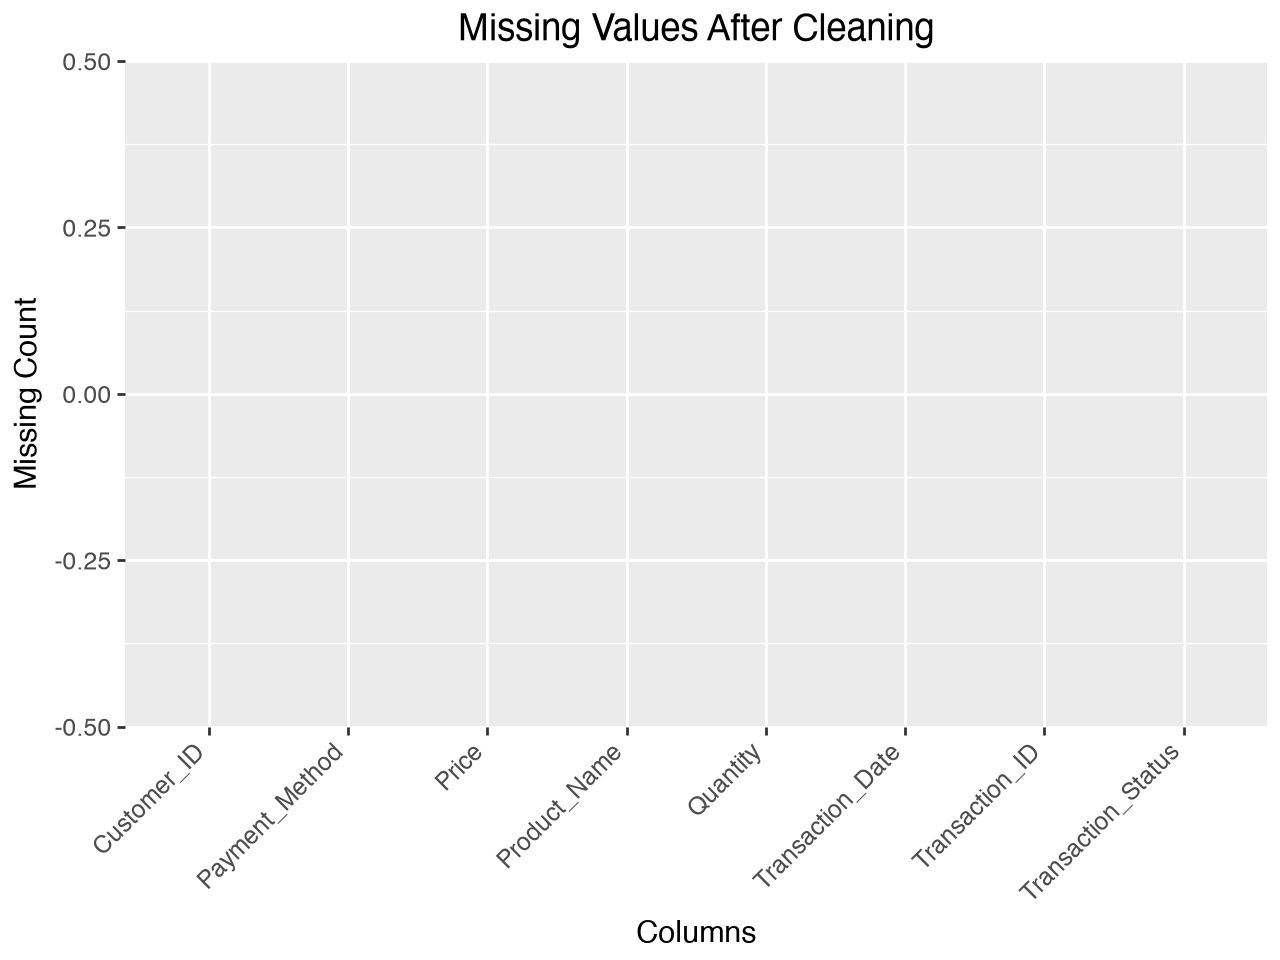

In [51]:
from plotnine import *

missing = clean_df.isnull().sum().reset_index()
missing.columns = ["Column", "Missing"]

(
    ggplot(missing, aes(x="Column", y="Missing"))
    + geom_col()
    + labs(
        title="Missing Values After Cleaning",
        x="Columns",
        y="Missing Count"
    )
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

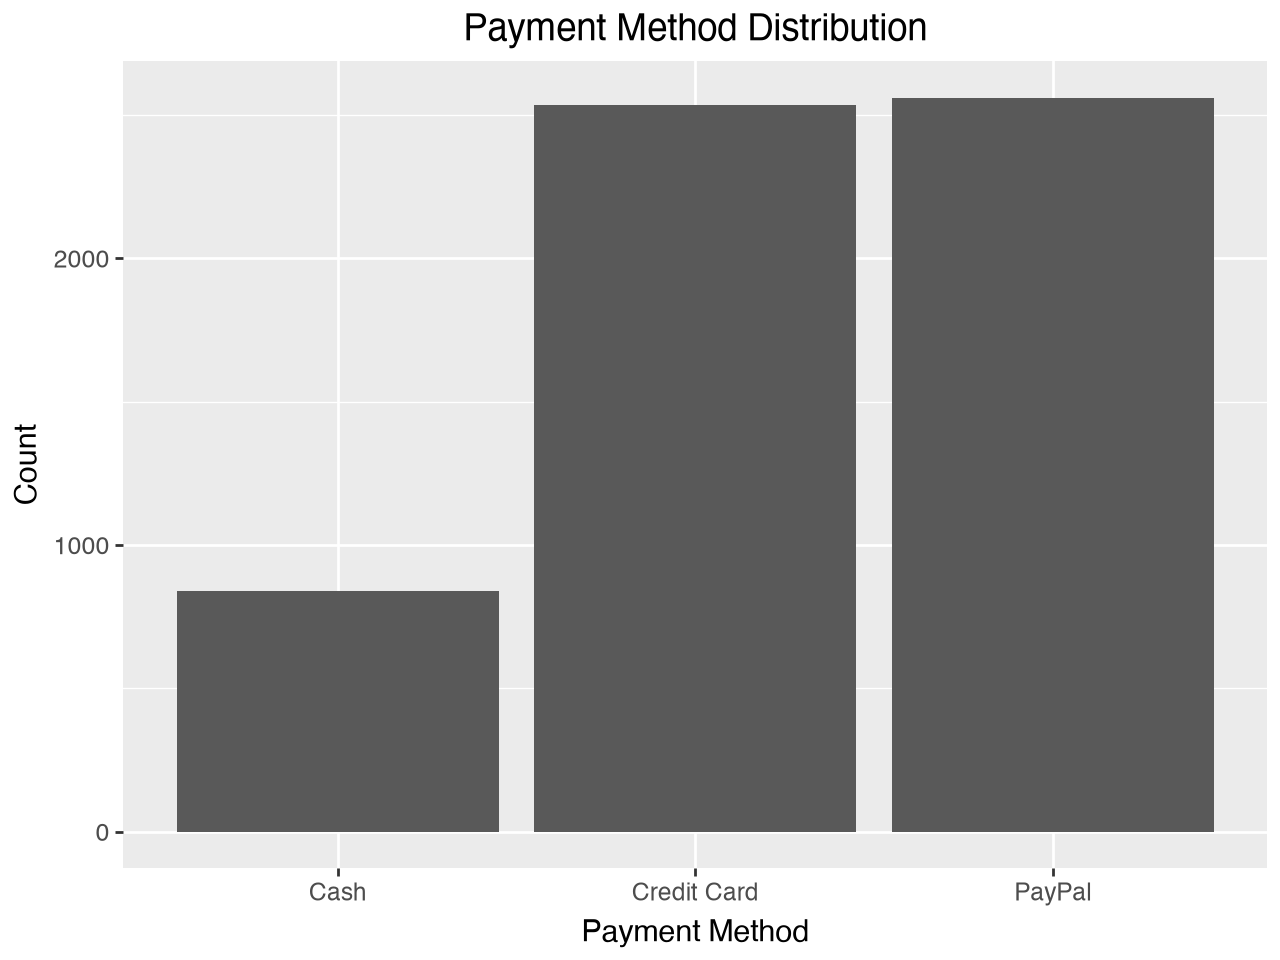

In [52]:
payment = clean_df["Payment_Method"].value_counts().reset_index()
payment.columns = ["Payment_Method", "Count"]

(
    ggplot(payment, aes(x="Payment_Method", y="Count"))
    + geom_col()
    + labs(
        title="Payment Method Distribution",
        x="Payment Method",
        y="Count"
    )
)

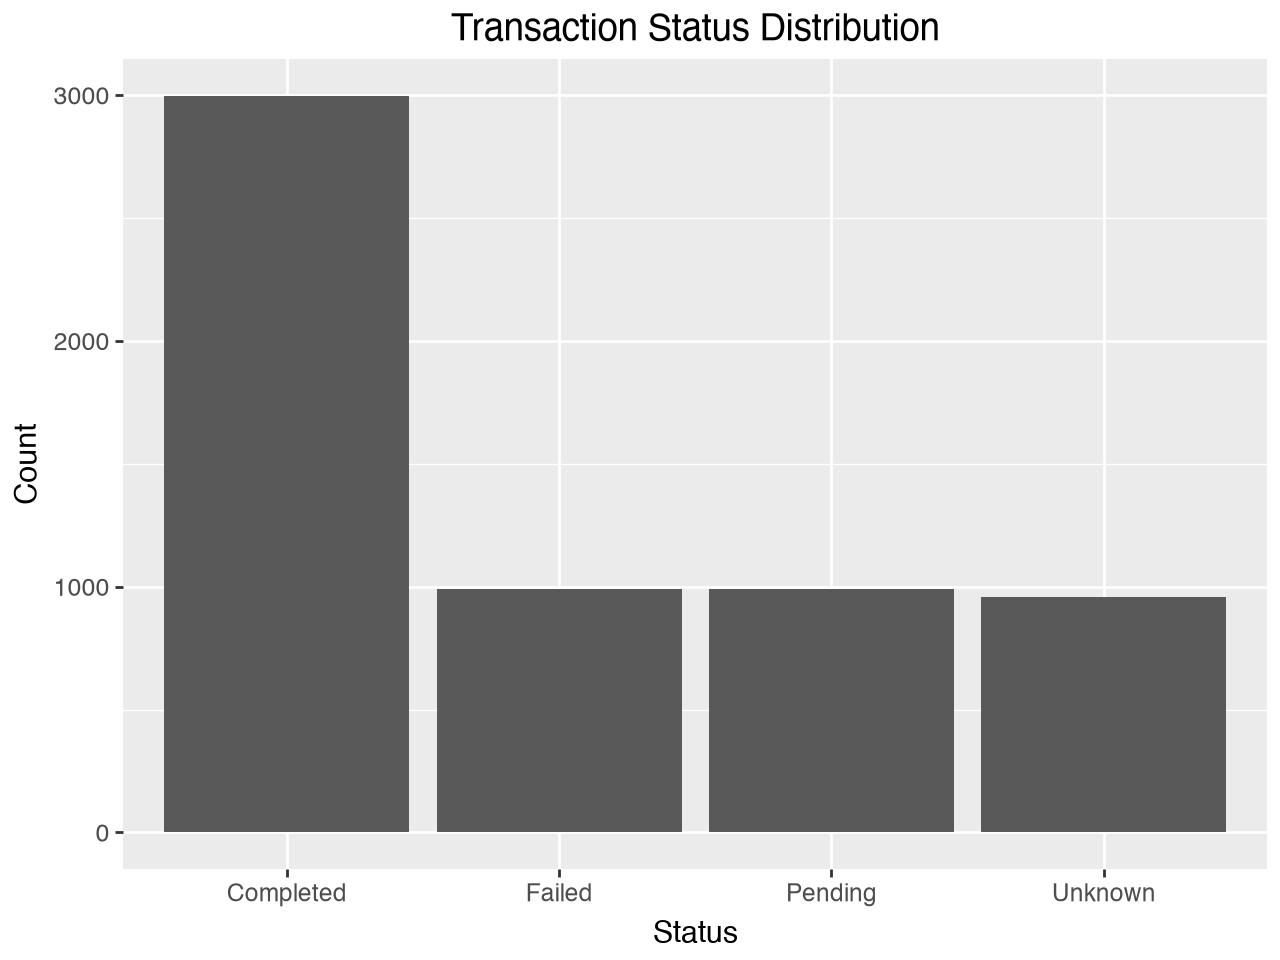

In [53]:
status = clean_df["Transaction_Status"].value_counts().reset_index()
status.columns = ["Transaction_Status", "Count"]

(
    ggplot(status, aes(x="Transaction_Status", y="Count"))
    + geom_col()
    + labs(
        title="Transaction Status Distribution",
        x="Status",
        y="Count"
    )
)

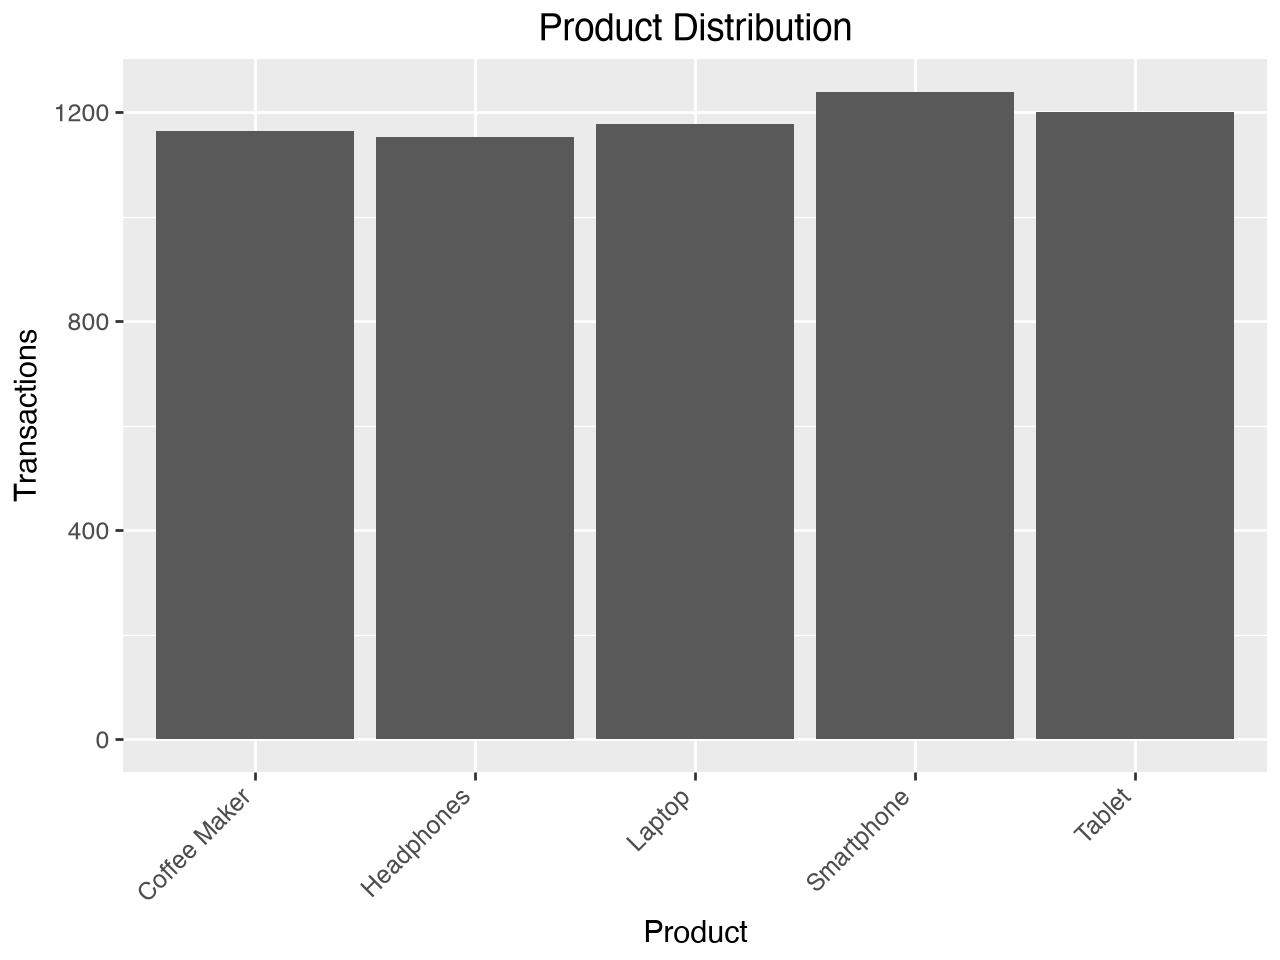

In [54]:
product = clean_df["Product_Name"].value_counts().reset_index()
product.columns = ["Product_Name", "Count"]

(
    ggplot(product, aes(x="Product_Name", y="Count"))
    + geom_col()
    + labs(
        title="Product Distribution",
        x="Product",
        y="Transactions"
    )
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

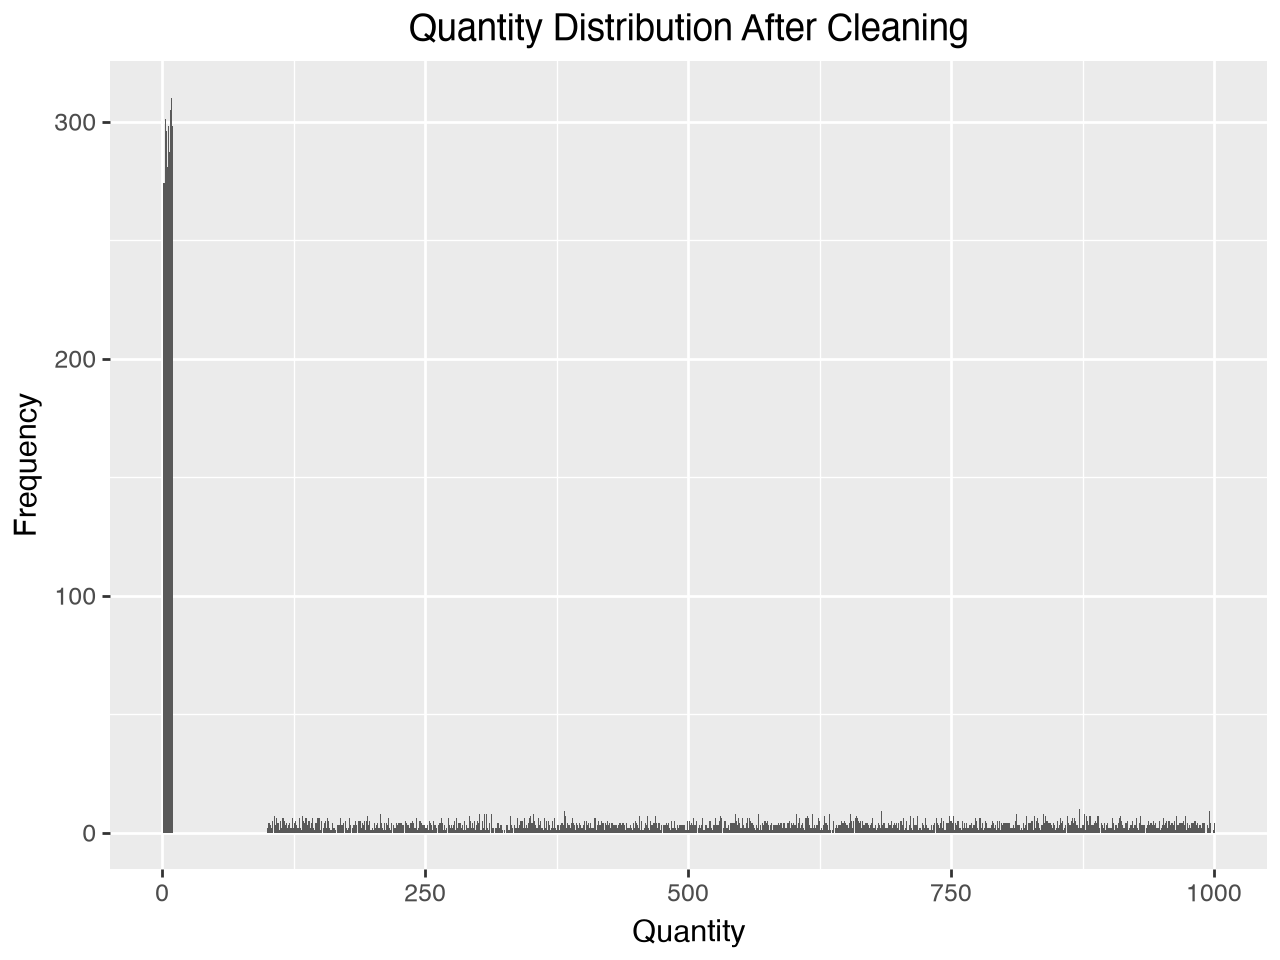

In [55]:
(
    ggplot(clean_df, aes(x="Quantity"))
    + geom_histogram(binwidth=1)
    + labs(
        title="Quantity Distribution After Cleaning",
        x="Quantity",
        y="Frequency"
    )
)

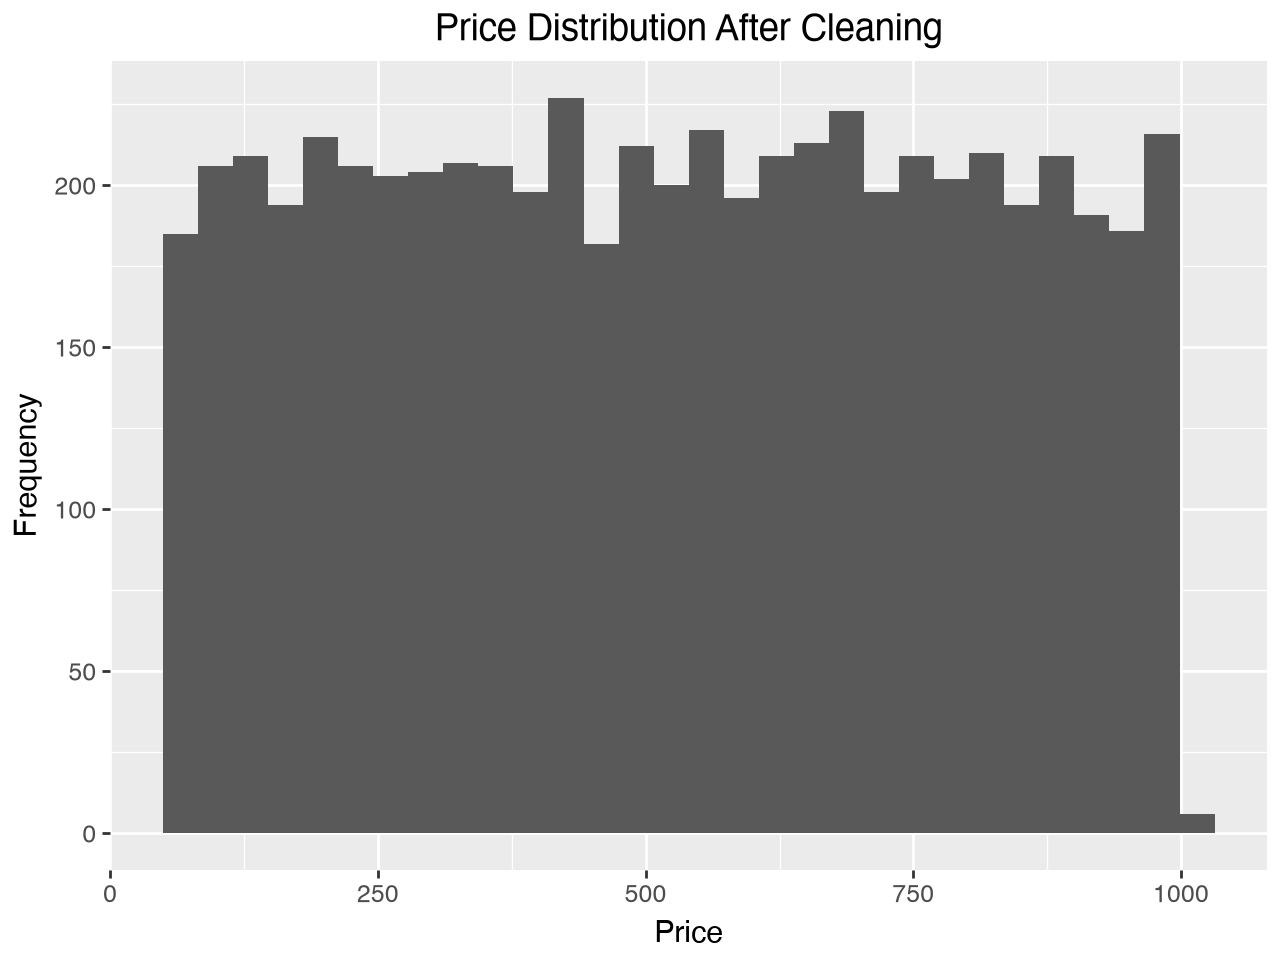

In [56]:
(
    ggplot(clean_df, aes(x="Price"))
    + geom_histogram(bins=30)
    + labs(
        title="Price Distribution After Cleaning",
        x="Price",
        y="Frequency"
    )
)

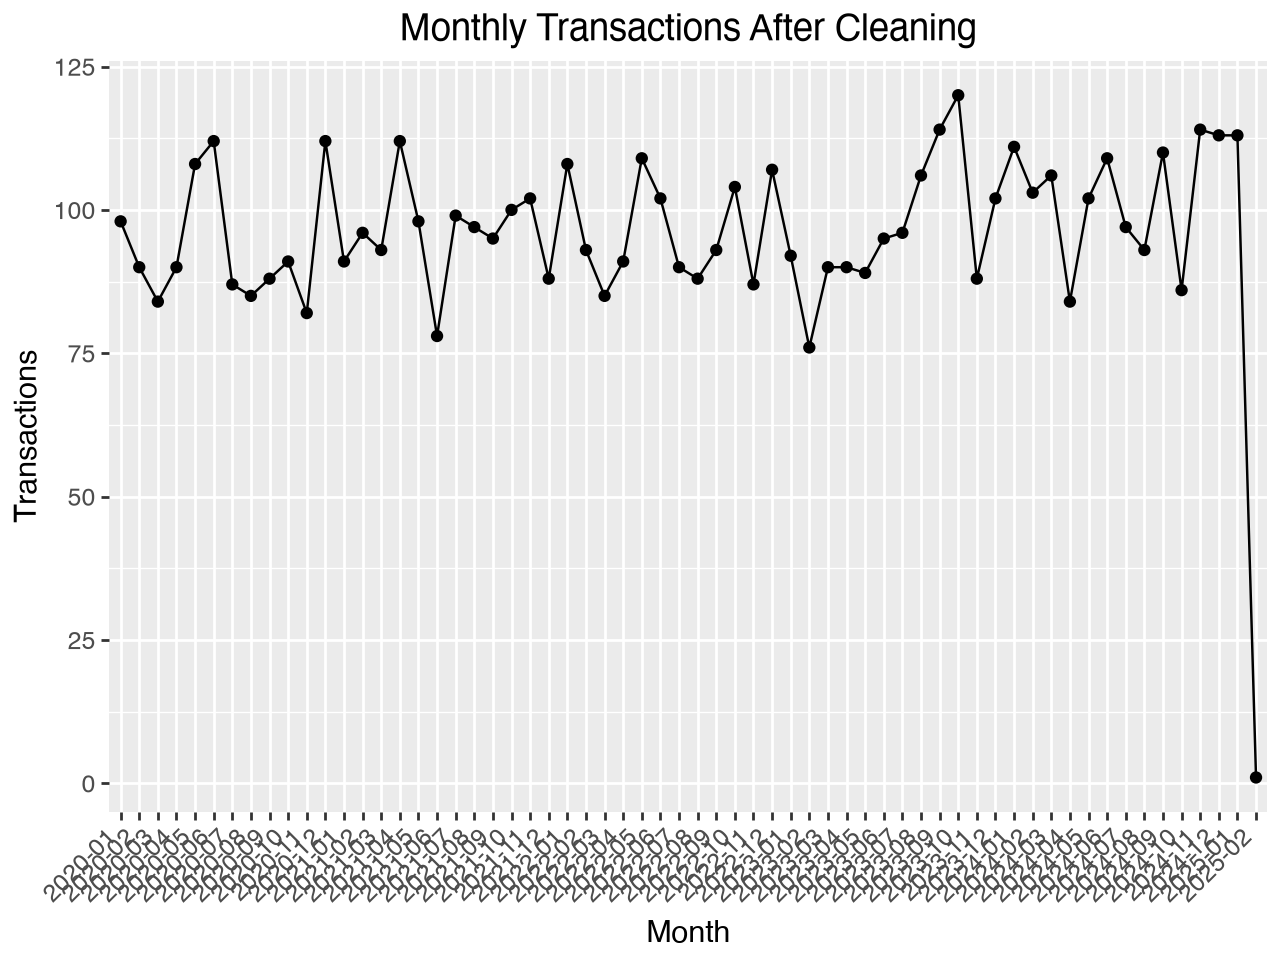

In [57]:
monthly = (
    clean_df
    .groupby(clean_df["Transaction_Date"].dt.to_period("M"))
    .size()
    .reset_index(name="Transactions")
)

monthly["Transaction_Date"] = monthly["Transaction_Date"].astype(str)

(
    ggplot(monthly, aes(x="Transaction_Date", y="Transactions", group=1))
    + geom_line()
    + geom_point()
    + labs(
        title="Monthly Transactions After Cleaning",
        x="Month",
        y="Transactions"
    )
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)